# Analitica de los datos obtenidos del sistema de Telemetria creado para el videojuego CronoPunk

## Librerias

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import re
from pathlib import Path
from collections import defaultdict
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

## Fase 1. Obtención y Organización de Eventos

En esta fase se tomaran los datos sacados por telemetria del JSON y se dividiran en los distintos tipos de eventos para poder usarlos en la representación grafica de las métricas para su posterior análisis.

In [4]:
#Establecemos la ruta donde se encuentran los archivos
ruta = "data/"

dataframes = []

#Recorremos los archivos de la carpeta que tiene los datos
for archivo in os.listdir(ruta):

    #revisamos que el archivo sea un .zip
    if archivo.endswith(".zip"):

        #Abrimos el archivo .zip y leemos el archivo JSON que contiene
        with zipfile.ZipFile(os.path.join(ruta, archivo)) as z:

            with z.open(z.namelist()[0]) as f:

                #Leemos el archivo JSON y lo convertimos en un DataFrame de pandas
                df = pd.read_json(f, orient="records")
                dataframes.append(df)

    #Carga JSON directo
    elif archivo.endswith(".json"):

        df = pd.read_json(os.path.join(ruta, archivo), orient="records")
        dataframes.append(df)

    #Carga CSV directo
    elif archivo.endswith(".csv"):
        df = pd.read_csv(os.path.join(ruta, archivo))
        dataframes.append(df)

#Concatenamos todos los DataFrames en uno solo
database = pd.concat(dataframes)

print(database.head())
print(database.shape)

     1             2             3  eventType                   timestamp  \
0  2.0  1.122880e+09  1.162656e+09          8  2026-04-16 10:52:19.573000   
1  2.0  1.122880e+09  1.162656e+09          0  2026-04-16 10:52:25.381000   
2  2.0  1.122880e+09  1.162656e+09          8  2026-04-16 10:52:27.254000   
3  2.0  1.122880e+09  1.162656e+09          0  2026-04-16 10:52:33.008000   
4  2.0  1.122880e+09  1.162656e+09          9  2026-04-16 10:52:41.516000   

           5          6   8   7   9  levelID  sessionID  userID  positionX  \
0        NaN        NaN NaN NaN NaN      NaN        NaN     NaN        NaN   
1   7.949773 -27.366060 NaN NaN NaN      NaN        NaN     NaN        NaN   
2        NaN        NaN NaN NaN NaN      NaN        NaN     NaN        NaN   
3  31.020901 -21.462042 NaN NaN NaN      NaN        NaN     NaN        NaN   
4        NaN        NaN NaN NaN NaN      NaN        NaN     NaN        NaN   

   positionY reason  shadowID  buttonID  leverID  
0        NaN    N

C:\Users\adria\AppData\Local\Temp\ipykernel_45320\477755570.py:24: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df = pd.read_json(os.path.join(ruta, archivo), orient="records")
C:\Users\adria\AppData\Local\Temp\ipykernel_45320\477755570.py:24: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df = pd.read_json(os.path.join(ruta, archivo), orient="records")
C:\Users\adria\AppData\Local\Temp\ipykernel_45320\477755570.py:24: FutureWarning: The behavior of 'to_datetime' with 'unit' when p

Division de la base de datos por los eventos especificos.

In [5]:
deathDB = database[database["eventType"] == 0]
endIterationDB = database[database["eventType"] == 1]
detFailureDB = database[database["eventType"] == 2]
leftGameDB = database[database["eventType"] == 3]
leftLevelDB = database[database["eventType"] == 4]
shadowSelectDB = database[database["eventType"] == 5]
buttonPressDB = database[database["eventType"] == 6]
leverActionDB = database[database["eventType"] == 7]
levelStartDB = database[database["eventType"] == 8]
levelEndDB = database[database["eventType"] == 9]

Division de la base de datos segun los usuarios

In [6]:
# Hacemos una lista de los usuarios, almacenando un dataframe por cada uno de estos.
datasetUsers = [df for _, df in database.groupby("userID")]

Variables que pueden ser utiles para futuros analisis y graficas

In [7]:
#Obtenemos todos los valores unicos que se han obtenido en levelID (Basicamente los niveles que se han testeado del juego)
levelIdsValues = database["levelID"].unique()

## Fase 2. Preparacion del layout de escenas y niveles

En esta fase se parsean los archivos de Unity para reconstruir la estructura espacial de cada nivel. El objetivo es dejar listos los datos de Grid y capas para que la fase de metricas solo tenga que renderizar.

### 2.1 Configuracion base del Grid y mapeo de escenas

Aqui se cargan rutas, GUID del prefab y metadatos base de Grid y capas para todos los niveles.

In [8]:
# Esta celda prepara la configuracion base del sistema de reconstruccion de niveles.
# Responsabilidades de la celda:
# 1) Definir rutas y constantes del prefab de Grid.
# 2) Parsear Grid.prefab para obtener metadatos de grid y capas.
# 3) Construir el mapa nivel -> escena y validar resultados por consola.
# -----------------------------------------------------------------------------------

LEVELS_DIR = Path("data/levels")
GRID_PREFAB_PATH = LEVELS_DIR / "Grid.prefab"
GRID_PREFAB_GUID = "4dddbf204a84a2241b315f01ca8c8f9a"


def _parse_vector3(vector_literal):
    # Convierte un literal tipo {x: a, y: b, z: c} en una tupla de floats.
    match = re.search(r"\{x:\s*([-\d.eE]+),\s*y:\s*([-\d.eE]+),\s*z:\s*([-\d.eE]+)\}", vector_literal)
    if not match:
        return (0.0, 0.0, 0.0)
    return tuple(float(value) for value in match.groups())


def parse_grid_prefab(prefab_path):
    # Lee el prefab completo y separa cada bloque serializado de Unity.
    text = prefab_path.read_text(encoding="utf-8")
    object_pattern = re.compile(
        r"^--- !u!(?P<type>\d+) &(?P<fileid>-?\d+)\n(?P<class>\w+):\n(?P<body>.*?)(?=^--- !u!|\Z)",
        re.MULTILINE | re.DOTALL,
    )

    # Estructuras auxiliares para relacionar componentes con GameObjects.
    gameobjects = {}
    transforms_by_gameobject = {}
    tilemaps = {}
    grid_component = None

    for match in object_pattern.finditer(text):
        file_id = int(match.group("fileid"))
        class_name = match.group("class")
        body = match.group("body")

        # Guardamos nombre y componentes de cada GameObject.
        if class_name == "GameObject":
            name_match = re.search(r"^\s*m_Name:\s*(.+)$", body, re.MULTILINE)
            name = name_match.group(1).strip() if name_match else f"GameObject_{file_id}"
            component_ids = [int(value) for value in re.findall(r"component:\s*\{fileID:\s*(-?\d+)\}", body)]
            gameobjects[file_id] = {
                "name": name,
                "components": component_ids,
            }

        # Relacionamos cada Transform con su GameObject padre.
        elif class_name == "Transform":
            gameobject_match = re.search(r"^\s*m_GameObject:\s*\{fileID:\s*(-?\d+)\}", body, re.MULTILINE)
            if gameobject_match:
                transforms_by_gameobject[int(gameobject_match.group(1))] = file_id

        # Capturamos metadatos de cada Tilemap definido en el prefab.
        elif class_name == "Tilemap":
            gameobject_match = re.search(r"^\s*m_GameObject:\s*\{fileID:\s*(-?\d+)\}", body, re.MULTILINE)
            origin_match = re.search(r"^\s*m_Origin:\s*(\{[^\n]+\})", body, re.MULTILINE)
            size_match = re.search(r"^\s*m_Size:\s*(\{[^\n]+\})", body, re.MULTILINE)
            tile_anchor_match = re.search(r"^\s*m_TileAnchor:\s*(\{[^\n]+\})", body, re.MULTILINE)
            if gameobject_match:
                tilemaps[file_id] = {
                    "gameobject_id": int(gameobject_match.group(1)),
                    "default_origin": _parse_vector3(origin_match.group(1)) if origin_match else (0.0, 0.0, 0.0),
                    "default_size": _parse_vector3(size_match.group(1)) if size_match else (0.0, 0.0, 0.0),
                    "tile_anchor": _parse_vector3(tile_anchor_match.group(1)) if tile_anchor_match else (0.5, 0.5, 0.0),
                }

        # Capturamos configuracion global del componente Grid.
        elif class_name == "Grid":
            gameobject_match = re.search(r"^\s*m_GameObject:\s*\{fileID:\s*(-?\d+)\}", body, re.MULTILINE)
            cell_size_match = re.search(r"^\s*m_CellSize:\s*(\{[^\n]+\})", body, re.MULTILINE)
            cell_gap_match = re.search(r"^\s*m_CellGap:\s*(\{[^\n]+\})", body, re.MULTILINE)
            cell_layout_match = re.search(r"^\s*m_CellLayout:\s*(-?\d+)", body, re.MULTILINE)
            cell_swizzle_match = re.search(r"^\s*m_CellSwizzle:\s*(-?\d+)", body, re.MULTILINE)
            if gameobject_match:
                grid_component = {
                    "component_id": file_id,
                    "gameobject_id": int(gameobject_match.group(1)),
                    "cell_size": _parse_vector3(cell_size_match.group(1)) if cell_size_match else (1.0, 1.0, 0.0),
                    "cell_gap": _parse_vector3(cell_gap_match.group(1)) if cell_gap_match else (0.0, 0.0, 0.0),
                    "cell_layout": int(cell_layout_match.group(1)) if cell_layout_match else 0,
                    "cell_swizzle": int(cell_swizzle_match.group(1)) if cell_swizzle_match else 0,
                }

    if grid_component is None:
        raise ValueError("No se encontro un componente Grid en Grid.prefab")

    # Construimos metadatos consolidados del Grid raiz.
    grid_go_id = grid_component["gameobject_id"]
    grid_transform_file_id = transforms_by_gameobject.get(grid_go_id)

    # Construimos metadatos por capa de Tilemap.
    layers = {}
    for tilemap_file_id, tilemap_data in tilemaps.items():
        gameobject_id = tilemap_data["gameobject_id"]
        layer_name = gameobjects.get(gameobject_id, {}).get("name", f"Layer_{tilemap_file_id}")
        layers[tilemap_file_id] = {
            "name": layer_name,
            "gameobject_id": gameobject_id,
            "transform_file_id": transforms_by_gameobject.get(gameobject_id),
            "default_origin": tilemap_data["default_origin"],
            "default_size": tilemap_data["default_size"],
            "tile_anchor": tilemap_data["tile_anchor"],
        }

    return {
        "grid": {
            "name": gameobjects.get(grid_go_id, {}).get("name", "Grid"),
            "gameobject_id": grid_go_id,
            "transform_file_id": grid_transform_file_id,
            "cell_size": grid_component["cell_size"],
            "cell_gap": grid_component["cell_gap"],
            "cell_layout": grid_component["cell_layout"],
            "cell_swizzle": grid_component["cell_swizzle"],
        },
        "layers": layers,
    }


# Mapeamos nivel numerico a su fichero de escena .unity.
level_scene_map = {
    int(scene_path.stem): scene_path
    for scene_path in sorted(LEVELS_DIR.glob("*.unity"), key=lambda path: int(path.stem))
    if scene_path.stem.isdigit()
}

# Parseamos Grid.prefab una sola vez para reutilizar metadatos en todo el pipeline.
prefab_meta = parse_grid_prefab(GRID_PREFAB_PATH)

# Resumen rapido para validar que la configuracion de entrada es correcta.
print("Niveles detectados:", sorted(level_scene_map.keys()))
print("Cell size del Grid:", prefab_meta["grid"]["cell_size"])
print("Capas encontradas en Grid.prefab:")
for layer_file_id, layer_info in sorted(prefab_meta["layers"].items(), key=lambda item: item[1]["name"]):
    print(f"  - {layer_info['name']} (Tilemap fileID: {layer_file_id})")

FileNotFoundError: [Errno 2] No such file or directory: 'data\\levels\\Grid.prefab'

### 2.2 Parseo de overrides y tiles por nivel

En este bloque se leen las escenas .unity para extraer transform del Grid, origen/tamano de capas y tiles efectivos de cada nivel.

In [ ]:
# Esta celda parsea cada escena .unity para obtener datos reales por nivel.
# Responsabilidades de la celda:
# 1) Leer overrides del PrefabInstance que apunta a Grid.prefab.
# 2) Extraer transform del Grid y tiles por capa.
# 3) Construir un resumen tabular para validacion rapida.
# -----------------------------------------------------------------------------------

def _to_int(value, default=0):
    # Convierte valores de texto a entero de forma segura.
    try:
        return int(float(value))
    except (TypeError, ValueError):
        return default


def _to_float(value, default=0.0):
    # Convierte valores de texto a float de forma segura.
    try:
        return float(value)
    except (TypeError, ValueError):
        return default


def parse_grid_prefab_overrides(scene_path, prefab_guid):
    # Lee la escena serializada de Unity y busca bloques PrefabInstance.
    text = scene_path.read_text(encoding="utf-8")
    instance_pattern = re.compile(
        r"^--- !u!1001 &(?P<instance_id>-?\d+)\nPrefabInstance:\n(?P<body>.*?)(?=^--- !u!|\Z)",
        re.MULTILINE | re.DOTALL,
    )
    property_pattern = re.compile(
        r"- target: \{fileID: (?P<file_id>-?\d+), guid: (?P<guid>[0-9a-f]+), type: 3\}\n"
        r"\s*propertyPath: (?P<property>[^\n]+)\n"
        r"\s*value: (?P<value>[^\n]*)",
        re.MULTILINE,
    )

    # Salida: fileID objetivo -> {propertyPath: value}.
    overrides_by_target = defaultdict(dict)

    for instance_match in instance_pattern.finditer(text):
        body = instance_match.group("body")
        source_match = re.search(r"m_SourcePrefab:\s*\{fileID:\s*100100000,\s*guid:\s*([0-9a-f]+),\s*type:\s*3\}", body)
        if not source_match:
            continue
        if source_match.group(1) != prefab_guid:
            continue

        # Solo guardamos propiedades de este prefab concreto.
        for prop_match in property_pattern.finditer(body):
            if prop_match.group("guid") != prefab_guid:
                continue
            target_file_id = int(prop_match.group("file_id"))
            property_name = prop_match.group("property").strip()
            property_value = prop_match.group("value").strip()
            overrides_by_target[target_file_id][property_name] = property_value

    return overrides_by_target


def parse_scene_grid(scene_path, prefab_meta, prefab_guid):
    # Combina metadatos del prefab con overrides de una escena concreta.
    level_id = int(scene_path.stem)
    overrides = parse_grid_prefab_overrides(scene_path, prefab_guid)

    # Transform final del Grid raiz en este nivel.
    grid_transform_id = prefab_meta["grid"]["transform_file_id"]
    grid_override = overrides.get(grid_transform_id, {})
    grid_position = (
        _to_float(grid_override.get("m_LocalPosition.x", 0.0)),
        _to_float(grid_override.get("m_LocalPosition.y", 0.0)),
        _to_float(grid_override.get("m_LocalPosition.z", 0.0)),
    )
    grid_rotation = (
        _to_float(grid_override.get("m_LocalRotation.x", 0.0)),
        _to_float(grid_override.get("m_LocalRotation.y", 0.0)),
        _to_float(grid_override.get("m_LocalRotation.z", 0.0)),
        _to_float(grid_override.get("m_LocalRotation.w", 1.0)),
    )
    grid_scale = (
        _to_float(grid_override.get("m_LocalScale.x", 1.0)),
        _to_float(grid_override.get("m_LocalScale.y", 1.0)),
        _to_float(grid_override.get("m_LocalScale.z", 1.0)),
    )

    # Recorremos capas conocidas en prefab y aplicamos overrides de escena.
    scene_layers = {}
    for layer_file_id, layer_info in prefab_meta["layers"].items():
        layer_override = overrides.get(layer_file_id, {})

        default_origin = layer_info["default_origin"]
        default_size = layer_info["default_size"]

        origin_x = _to_int(layer_override.get("m_Origin.x", default_origin[0]))
        origin_y = _to_int(layer_override.get("m_Origin.y", default_origin[1]))
        size_x = _to_int(layer_override.get("m_Size.x", default_size[0]))
        size_y = _to_int(layer_override.get("m_Size.y", default_size[1]))
        tile_count = _to_int(layer_override.get("m_Tiles.Array.size", 0))

        # Extraemos coordenadas de cada tile pintado en esta capa.
        tiles = []
        for index in range(tile_count):
            x_key = f"m_Tiles.Array.data[{index}].first.x"
            y_key = f"m_Tiles.Array.data[{index}].first.y"
            if x_key not in layer_override or y_key not in layer_override:
                continue

            tile_x = _to_int(layer_override.get(x_key))
            tile_y = _to_int(layer_override.get(y_key))
            tile_index_key = f"m_Tiles.Array.data[{index}].second.m_TileIndex"
            tile_index = _to_int(layer_override.get(tile_index_key), default=-1)
            tiles.append((tile_x, tile_y, tile_index))

        scene_layers[layer_file_id] = {
            "name": layer_info["name"],
            "origin": (origin_x, origin_y),
            "size": (size_x, size_y),
            "tiles": tiles,
            "tile_count": tile_count,
        }

    return {
        "level_id": level_id,
        "scene_path": str(scene_path),
        "grid": {
            "position": grid_position,
            "rotation": grid_rotation,
            "scale": grid_scale,
            "cell_size": prefab_meta["grid"]["cell_size"],
            "cell_gap": prefab_meta["grid"]["cell_gap"],
            "cell_layout": prefab_meta["grid"]["cell_layout"],
            "cell_swizzle": prefab_meta["grid"]["cell_swizzle"],
        },
        "layers": scene_layers,
    }


# Parseamos todas las escenas detectadas en el paso anterior.
scene_grid_data = {
    level_id: parse_scene_grid(scene_path, prefab_meta, GRID_PREFAB_GUID)
    for level_id, scene_path in sorted(level_scene_map.items())
}

# Construimos una tabla compacta de control por nivel.
scene_summary_rows = []
for level_id, level_data in scene_grid_data.items():
    total_tiles = sum(layer["tile_count"] for layer in level_data["layers"].values())
    non_empty_layers = sum(1 for layer in level_data["layers"].values() if layer["tile_count"] > 0)
    grid_x, grid_y, grid_z = level_data["grid"]["position"]
    scene_summary_rows.append(
        {
            "levelID": level_id,
            "gridPosX": grid_x,
            "gridPosY": grid_y,
            "gridPosZ": grid_z,
            "layers": len(level_data["layers"]),
            "nonEmptyLayers": non_empty_layers,
            "totalTiles": total_tiles,
        }
    )

scene_grid_summary_df = pd.DataFrame(scene_summary_rows).sort_values("levelID").reset_index(drop=True)
scene_grid_summary_df

,levelID,gridPosX,gridPosY,gridPosZ,layers,nonEmptyLayers,totalTiles
0,1,-1.4,-17.3,0.0,4,2,271
1,2,-1.4,-17.3,0.0,4,3,524
2,3,-1.4,-17.3,0.0,4,2,756
3,4,-1.4,-17.3,0.0,4,3,558
4,5,-1.4,-17.3,0.0,4,2,531
5,6,-1.4,-17.3,0.0,4,2,559
6,7,-1.4,-17.3,0.0,4,3,426
7,8,-1.4,-17.3,0.0,4,3,873
8,9,-1.4,-17.3,0.0,4,3,788
9,10,-1.4,-17.3,0.0,4,3,992


### 2.3 Construccion de matrices y utilidades de visualizacion

Aqui se preparan las matrices por capa y se definen helpers de render y conversion mundo-grid para la fase de metricas.

In [ ]:
# Esta celda transforma los tiles parseados en matrices binarias por nivel y capa.
# Responsabilidades de la celda:
# 1) Calcular bounds de trabajo por nivel.
# 2) Generar una matriz 2D por capa (0 vacio, 1 tile).
# 3) Publicar un resumen de dimensiones para chequeo rapido.
# -----------------------------------------------------------------------------------

def _compute_level_bounds(level_data):
    # Ajustamos el marco al contenido real (tiles pintados) para evitar huecos grandes.
    tile_coords = [
        (tile_x, tile_y)
        for layer in level_data["layers"].values()
        for tile_x, tile_y, _ in layer["tiles"]
    ]

    if tile_coords:
        xs, ys = zip(*tile_coords)
        return (int(min(xs)), int(max(xs)), int(min(ys)), int(max(ys)))

    # Fallback: si un nivel no tiene tiles, usamos el bounding por origin/size.
    min_x, min_y = np.inf, np.inf
    max_x, max_y = -np.inf, -np.inf

    for layer in level_data["layers"].values():
        origin_x, origin_y = layer["origin"]
        size_x, size_y = layer["size"]
        if size_x > 0 and size_y > 0:
            min_x = min(min_x, origin_x)
            min_y = min(min_y, origin_y)
            max_x = max(max_x, origin_x + size_x - 1)
            max_y = max(max_y, origin_y + size_y - 1)

    if not np.isfinite(min_x):
        return (0, 0, 0, 0)

    return (int(min_x), int(max_x), int(min_y), int(max_y))


def _build_layer_matrix(layer_data, bounds):
    # Proyecta tiles de una capa a una matriz local segun bounds del nivel.
    min_x, max_x, min_y, max_y = bounds
    width = max_x - min_x + 1
    height = max_y - min_y + 1
    matrix = np.zeros((height, width), dtype=np.uint8)

    for tile_x, tile_y, _ in layer_data["tiles"]:
        col = tile_x - min_x
        row = tile_y - min_y
        if 0 <= row < height and 0 <= col < width:
            matrix[row, col] = 1

    return matrix


def build_level_grid_matrices(scene_data):
    # Construye el diccionario final: level -> bounds + matrices por capa.
    matrix_data = {}
    for level_id, level_data in scene_data.items():
        bounds = _compute_level_bounds(level_data)
        layer_matrices = {}
        for layer_file_id, layer_data in level_data["layers"].items():
            layer_matrices[layer_file_id] = _build_layer_matrix(layer_data, bounds)
        matrix_data[level_id] = {
            "bounds": bounds,
            "layer_matrices": layer_matrices,
        }
    return matrix_data


# Ejecutamos la preparacion de matrices para todos los niveles.
level_grid_matrices = build_level_grid_matrices(scene_grid_data)

# Tabla de apoyo para verificar dimensiones y limites por nivel.
matrix_summary_rows = []
for level_id in sorted(level_grid_matrices.keys()):
    min_x, max_x, min_y, max_y = level_grid_matrices[level_id]["bounds"]
    matrix_summary_rows.append({
        "levelID": level_id,
        "minX": min_x,
        "maxX": max_x,
        "minY": min_y,
        "maxY": max_y,
        "ancho": max_x - min_x + 1,
        "alto": max_y - min_y + 1,
    })

matrix_bounds_summary_df = pd.DataFrame(matrix_summary_rows)
matrix_bounds_summary_df

,levelID,minX,maxX,minY,maxY,ancho,alto
0,1,-19,31,-10,4,51,15
1,2,-12,44,-10,18,57,29
2,3,-29,16,-11,10,46,22
3,4,-18,38,-11,7,57,19
4,5,-16,36,-17,-3,53,15
5,6,-16,37,-11,10,54,22
6,7,-15,48,-10,9,64,20
7,8,-12,46,-14,25,59,40
8,9,-22,100,-9,7,123,17
9,10,-16,43,-22,12,60,35


In [ ]:
# Esta celda define funciones de visualizacion reutilizables.
# Responsabilidades de la celda:
# 1) Dibujar layouts de niveles desde matrices binarias.
# 2) Convertir eventos del mundo a coordenadas de grid.
# 3) Mantener la fase de metricas enfocada solo en render.
# -----------------------------------------------------------------------------------

# Mapa base editable: nombre de capa -> color.
# Se puede anadir aqui cualquier capa del prefab, por ejemplo:
# "Terrain", "Background", "Foreground", "KillOnCollide".
DEFAULT_LAYER_COLORS = {
    "KillOnCollide": "#FFCF4B",
}

def _plot_optional_events(axis, level_id, event_points_by_level=None):
    # Dibuja puntos de evento solo si se reciben datos para el nivel.
    if not event_points_by_level:
        return

    level_events = event_points_by_level.get(level_id, [])
    for event in level_events:
        x = event.get("x")
        y = event.get("y")
        if x is None or y is None:
            continue

        marker = event.get("marker", "o")
        edgecolor = event.get("edgecolor", "none")
        scatter_kwargs = {
            "c": event.get("color", "black"),
            "marker": marker,
            "s": event.get("size", 36),
            "alpha": event.get("alpha", 0.9),
            "label": event.get("label", None),
        }

        # Evitamos warning de matplotlib con marcadores no rellenables como 'x'.
        if marker not in {"x", "+", "1", "2", "3", "4", "|", "_"}:
            scatter_kwargs["edgecolors"] = edgecolor

        axis.scatter(x, y, **scatter_kwargs)


def _world_to_grid_coordinates(world_x, world_y, level_data):
    # Convierte posicion en mundo a coordenada de grid usando offset y cell size del nivel.
    grid_pos_x, grid_pos_y, _ = level_data["grid"]["position"]
    cell_size_x, cell_size_y, _ = level_data["grid"]["cell_size"]
    if cell_size_x == 0 or cell_size_y == 0:
        return (None, None)

    grid_x = (world_x - grid_pos_x) / cell_size_x
    grid_y = (world_y - grid_pos_y) / cell_size_y
    return (grid_x, grid_y)


def build_event_points_by_level(
    events_df,
    scene_data,
    color="black",
    marker="o",
    label=None,
    size=36,
    alpha=0.9,
    edgecolor="none",
    ):
    # Genera el diccionario levelID -> lista de puntos listos para overlay.
    required_columns = {"levelID", "positionX", "positionY"}
    if events_df is None or events_df.empty:
        return {}
    if not required_columns.issubset(set(events_df.columns)):
        return {}

    points_by_level = defaultdict(list)
    valid_rows = events_df.dropna(subset=["levelID", "positionX", "positionY"])
    for _, row in valid_rows.iterrows():
        level_id = int(row["levelID"])
        if level_id not in scene_data:
            continue

        grid_x, grid_y = _world_to_grid_coordinates(
            world_x=float(row["positionX"]),
            world_y=float(row["positionY"]),
            level_data=scene_data[level_id],
        )
        if grid_x is None or grid_y is None:
            continue

        points_by_level[level_id].append(
            {
                "x": grid_x,
                "y": grid_y,
                "color": color,
                "marker": marker,
                "size": size,
                "alpha": alpha,
                "label": label,
                "edgecolor": edgecolor,
            }
        )

    return dict(points_by_level)


def plot_reconstructed_grids(
    scene_data,
    matrix_data,
    max_cols=1,
    include_empty_layers=False,
    margin_cells=1.0,
    event_points_by_level=None,
    show_event_legend=False,
    represented_data_label=None,
    layer_colors=None,
    palette_name="tab10",
    ):
    # Funcion principal de render por nivel.
    level_ids = sorted(scene_data.keys())
    if not level_ids:
        raise ValueError("No hay niveles parseados para visualizar")

    # Combina colores por defecto con overrides opcionales del usuario.
    resolved_layer_colors = dict(DEFAULT_LAYER_COLORS)
    if layer_colors:
        resolved_layer_colors.update(layer_colors)

    max_cols = max(1, max_cols)
    rows = int(np.ceil(len(level_ids) / max_cols))
    axes = plt.subplots(rows, max_cols, figsize=(12 * max_cols, 4.8 * rows), squeeze=False)[1]
    axes_flat = axes.ravel()

    for axis, level_id in zip(axes_flat, level_ids):
        level_data = scene_data[level_id]
        bounds = matrix_data[level_id]["bounds"]
        min_x, max_x, min_y, max_y = bounds

        layer_items = list(level_data["layers"].items())
        palette = plt.get_cmap(palette_name, max(1, len(layer_items)))

        legend_handles = []
        plotted_layers = 0

        # Pintamos cada capa con color configurable por nombre de capa.
        for layer_index, (layer_file_id, layer_info) in enumerate(layer_items):
            matrix = matrix_data[level_id]["layer_matrices"][layer_file_id]
            if matrix.size == 0:
                continue
            if not include_empty_layers and matrix.sum() == 0:
                continue

            layer_label = layer_info["name"] if layer_info["name"] else f"Layer {layer_file_id}"
            layer_color = resolved_layer_colors.get(layer_label, palette(layer_index))
            mask = np.ma.masked_where(matrix == 0, matrix)

            axis.imshow(
                mask,
                origin="lower",
                interpolation="nearest",
                extent=(min_x - 0.5, max_x + 0.5, min_y - 0.5, max_y + 0.5),
                cmap=ListedColormap([layer_color]),
                alpha=0.72,
            )

            legend_handles.append(Patch(facecolor=layer_color, edgecolor="none", label=layer_label))
            plotted_layers += 1

        # Hook para eventos telemetricos (muertes, fin iteracion, etc.).
        _plot_optional_events(axis, level_id, event_points_by_level=event_points_by_level)

        grid_pos_x, grid_pos_y, _ = level_data["grid"]["position"]
        title_parts = [f"Nivel {level_id}", f"Grid Pos: ({grid_pos_x:.2f}, {grid_pos_y:.2f})"]
        if represented_data_label:
            title_parts.append(represented_data_label)
        axis.set_title(" | ".join(title_parts))
        axis.set_xlabel("Grid X")
        axis.set_ylabel("Grid Y")
        axis.set_aspect("equal")
        axis.set_xlim(min_x - 0.5 - margin_cells, max_x + 0.5 + margin_cells)
        axis.set_ylim(min_y - 0.5 - margin_cells, max_y + 0.5 + margin_cells)
        axis.grid(True, color="lightgray", linewidth=0.3, alpha=0.4)

        if legend_handles:
            axis.legend(handles=legend_handles, loc="upper right", fontsize=8, framealpha=0.95)
        if show_event_legend and event_points_by_level:
            axis.legend(loc="upper left", fontsize=8, framealpha=0.95)
        if plotted_layers == 0:
            axis.text(0.5, 0.5, "Sin capas con tiles", ha="center", va="center", transform=axis.transAxes)

    # Ocultamos ejes sobrantes cuando la rejilla de subplots tiene huecos.
    for axis in axes_flat[len(level_ids):]:
        axis.axis("off")

    plt.tight_layout()
    plt.show()

## Fase 3. Visualizacion grafica de las métricas calculadas

En esta fase se muestran las celdas de render para cada metrica espacial y para las metricas de barras.

### Distribucion espacial de las muertes del jugador

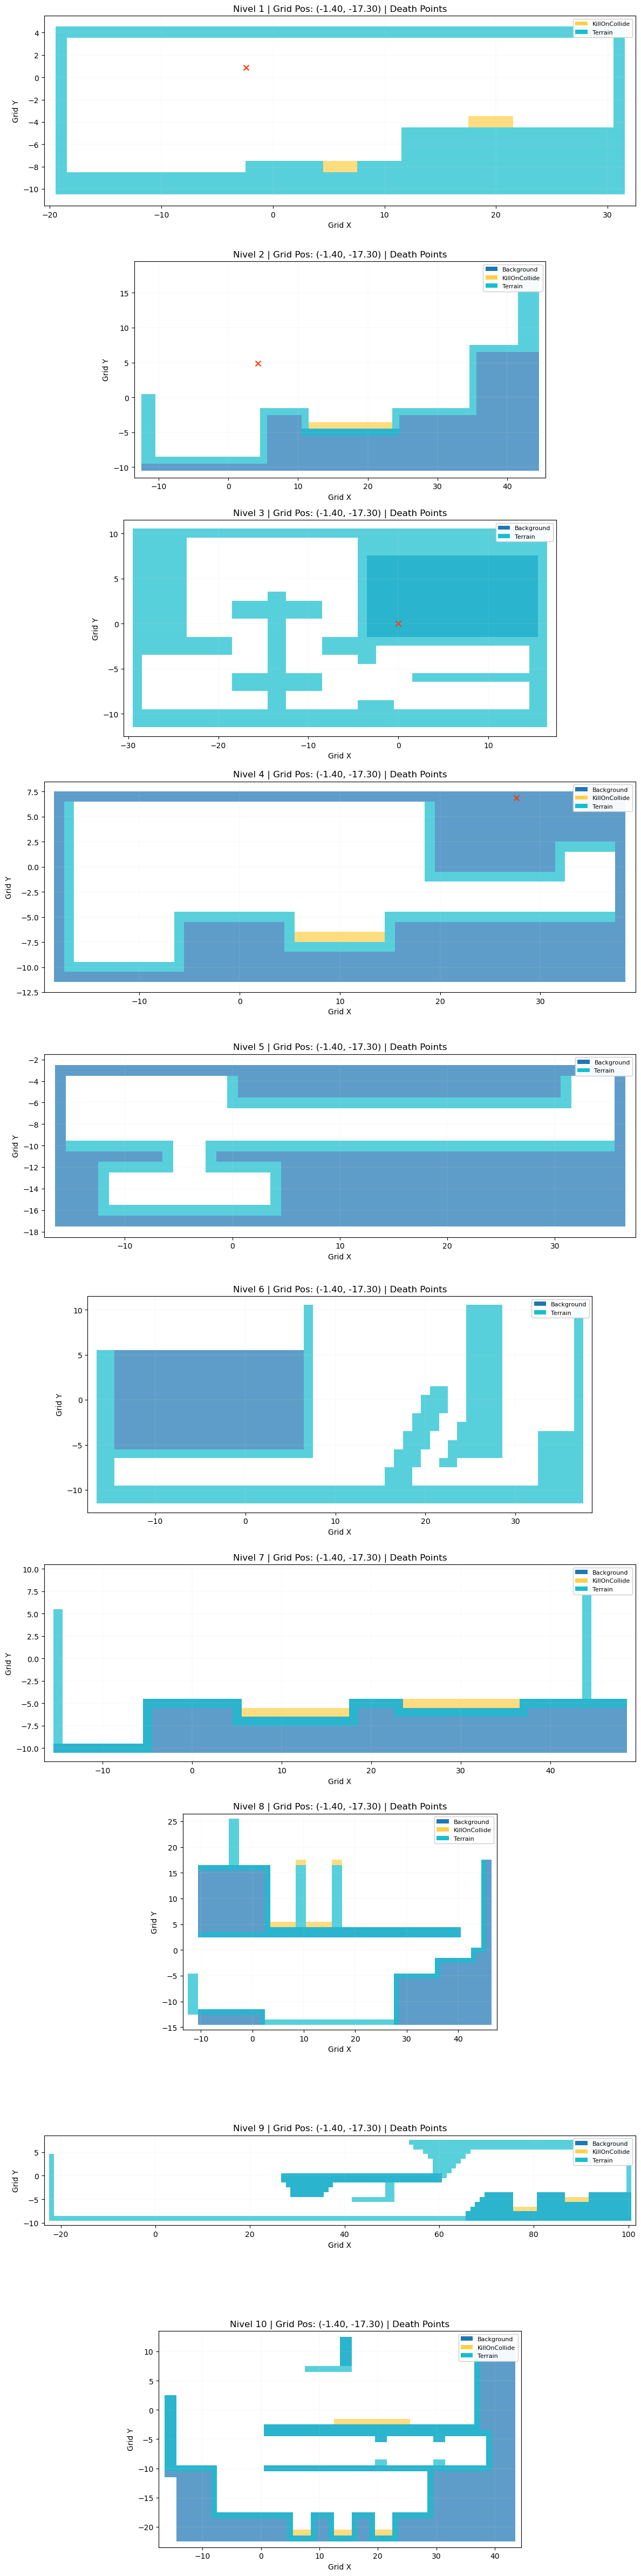

In [ ]:
# Render de la metrica espacial de muertes del jugador.
death_points_by_level = build_event_points_by_level(
    events_df=deathDB,
    scene_data=scene_grid_data,
    color="#FF3300",
    marker="x",
    label="Muerte",
    size=50,
    alpha=1.0,
    edgecolor="white",
    )

plot_reconstructed_grids(
    scene_data=scene_grid_data,
    matrix_data=level_grid_matrices,
    max_cols=1,
    include_empty_layers=False,
    margin_cells=1.0,
    event_points_by_level=death_points_by_level,
    show_event_legend=False,
    represented_data_label="Death Points",
    )

### Distribucion espacial del fin de iteracion del jugador

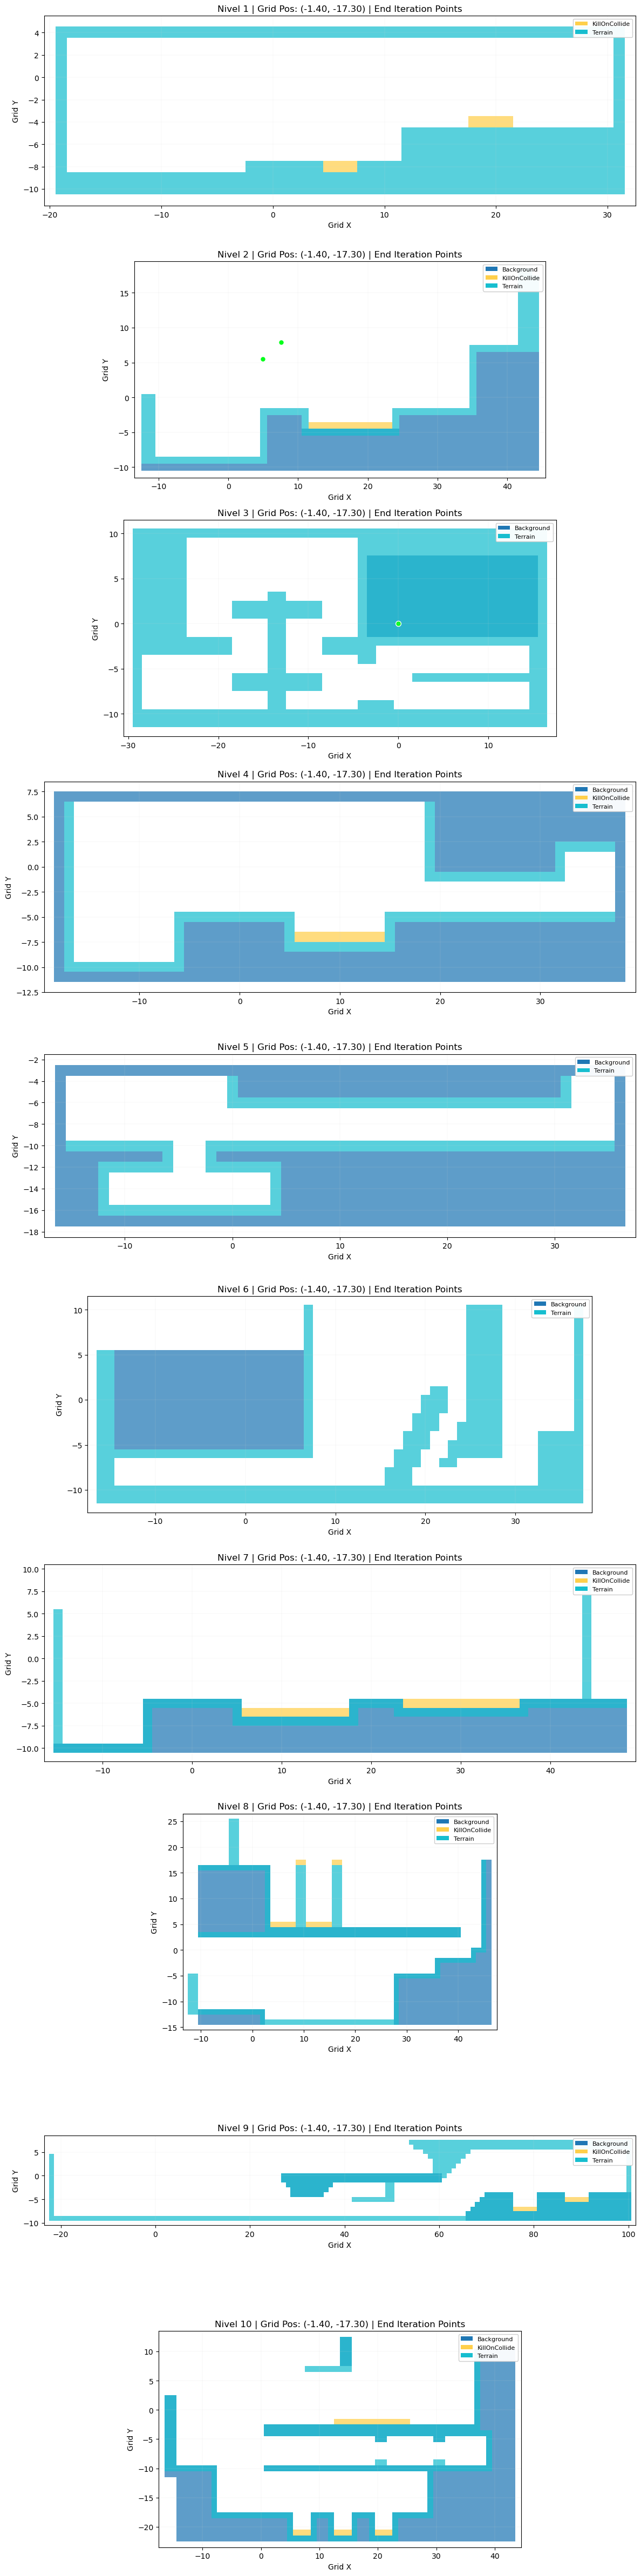

In [ ]:
# Render de la metrica espacial de fin de iteracion.
end_iteration_points_by_level = build_event_points_by_level(
    events_df=endIterationDB,
    scene_data=scene_grid_data,
    color="#00FF1A",
    marker="o",
    label="Fin iteracion",
    size=50,
    alpha=1.0,
    edgecolor="white",
    )

plot_reconstructed_grids(
    scene_data=scene_grid_data,
    matrix_data=level_grid_matrices,
    max_cols=1,
    include_empty_layers=False,
    margin_cells=1.0,
    event_points_by_level=end_iteration_points_by_level,
    show_event_legend=False,
    represented_data_label="End Iteration Points",
    )

### Posicion de fallos de determinismo

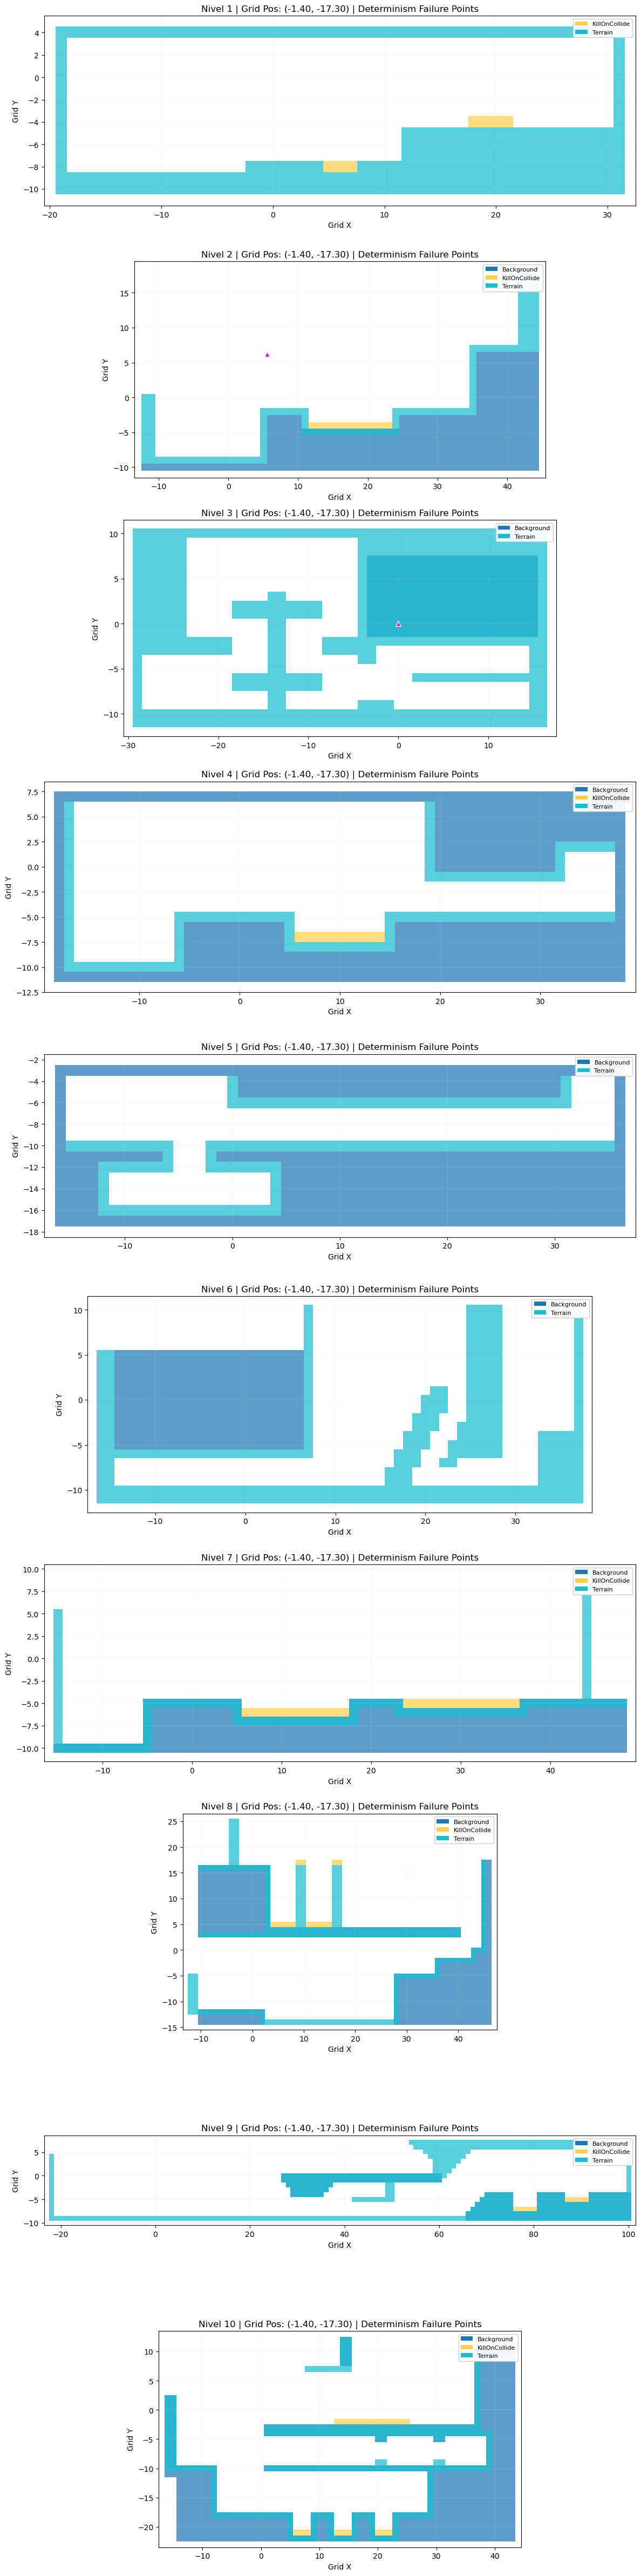

In [ ]:
# Render de la metrica espacial de fallos de determinismo.
det_failure_points_by_level = build_event_points_by_level(
    events_df=detFailureDB,
    scene_data=scene_grid_data,
    color="#FF00D4",
    marker="^",
    label="Fallo determinismo",
    size=50,
    alpha=1.0,
    edgecolor="white",
    )

plot_reconstructed_grids(
    scene_data=scene_grid_data,
    matrix_data=level_grid_matrices,
    max_cols=1,
    include_empty_layers=False,
    margin_cells=1.0,
    event_points_by_level=det_failure_points_by_level,
    show_event_legend=False,
    represented_data_label="Determinism Failure Points",
    )

### Tasa de abandono por nivel

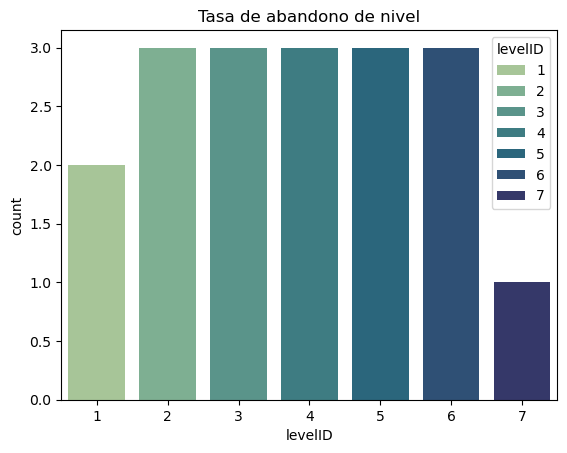

In [ ]:
ax = sns.countplot(x="levelID", data=leftLevelDB, hue="levelID", palette = "crest", order=sorted(leftLevelDB["levelID"].unique()))
ax.set_title("Tasa de abandono de nivel")
ax.tick_params(axis='x', rotation=0)

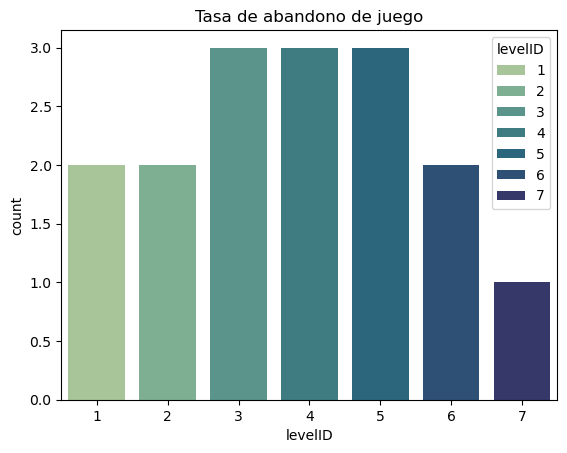

In [ ]:
ax = sns.countplot(x="levelID", data=leftGameDB, hue="levelID", palette = "crest", order=sorted(leftGameDB["levelID"].unique()))
ax.set_title("Tasa de abandono de juego")
ax.tick_params(axis='x', rotation=0)

### Número total de iteraciones hechas (totales y por cada sombra) en un nivel

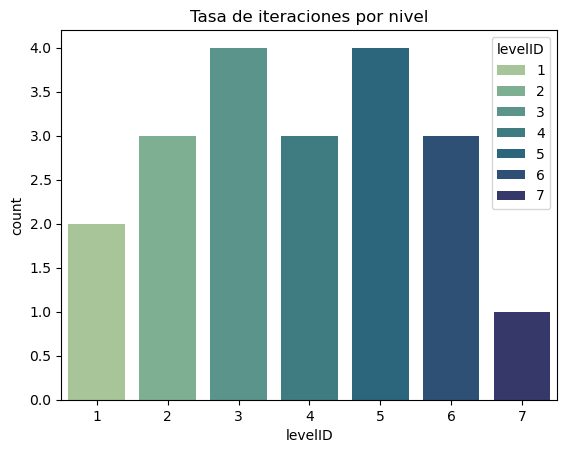

In [ ]:
ax = sns.countplot(x="levelID", data=endIterationDB, hue="levelID", palette = "crest")
ax.set_title("Tasa de iteraciones por nivel")
ax.tick_params(axis='x', rotation=0)

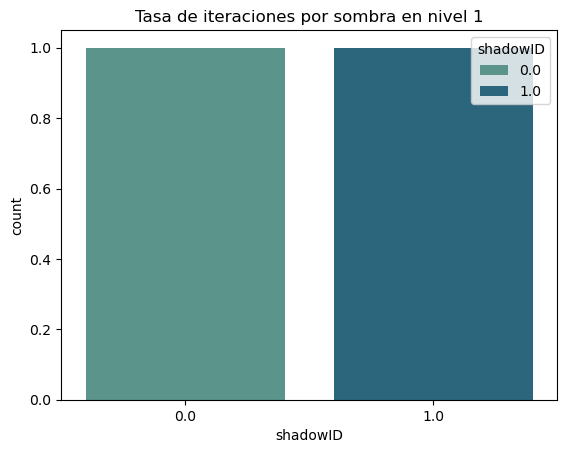

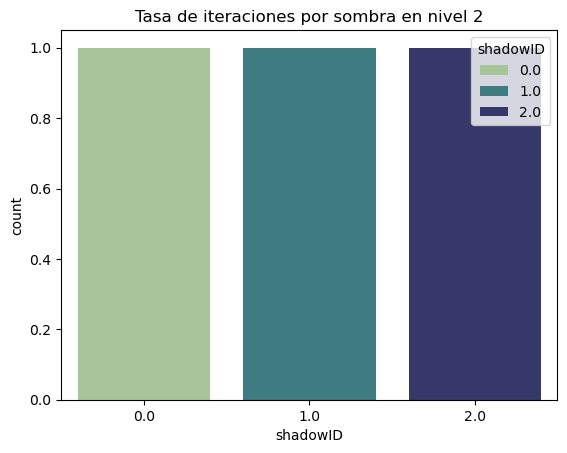

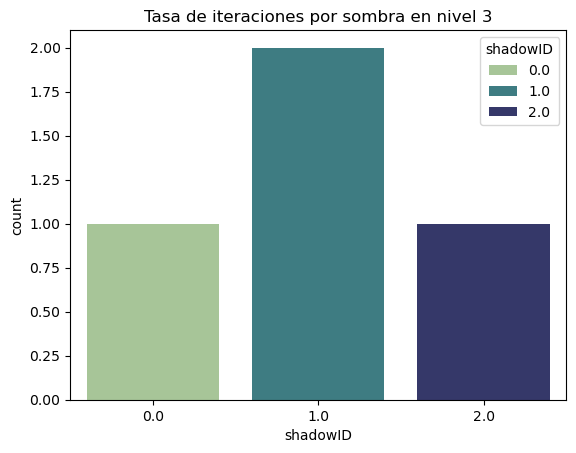

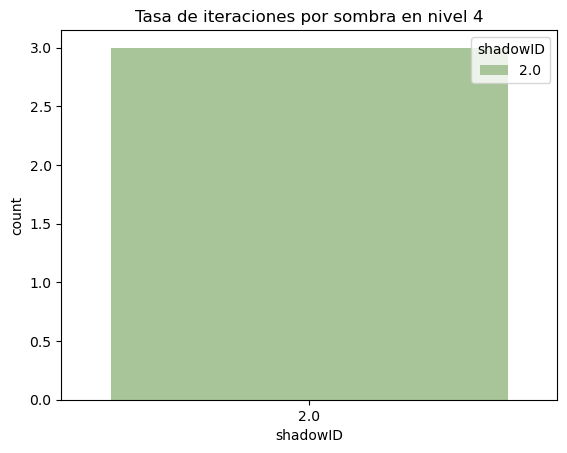

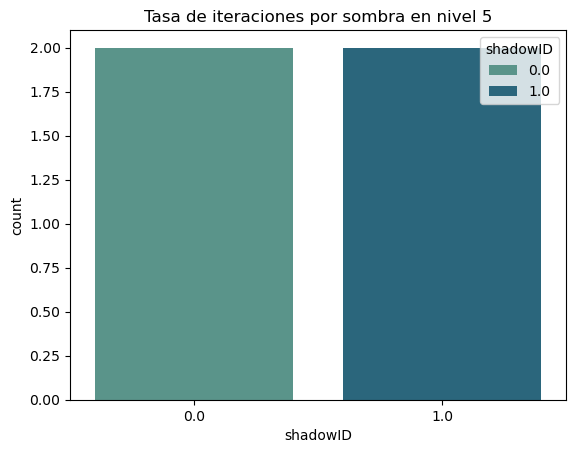

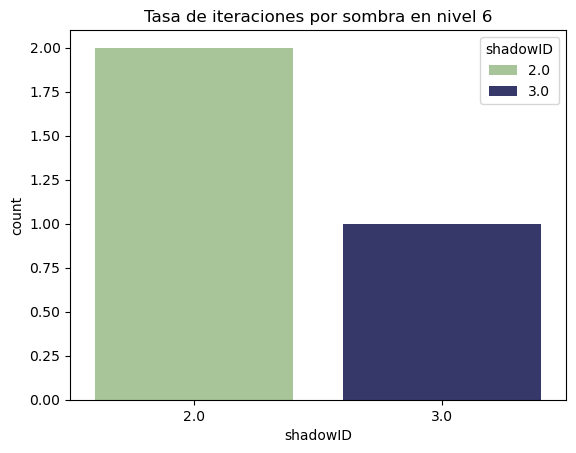

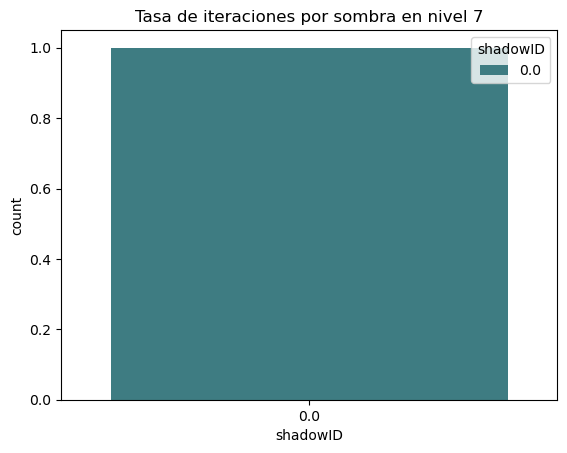

In [ ]:
endIterationLevelsDS = []

for level in levelIdsValues:
    endIterationLevelsDS.append(endIterationDB[endIterationDB["levelID"] == level])

for dataset in endIterationLevelsDS:
    ax = sns.countplot(x="shadowID", data=dataset, hue="shadowID", palette = "crest")
    ax.set_title("Tasa de iteraciones por sombra en nivel " + str(dataset["levelID"].iloc[0]))
    ax.tick_params(axis='x', rotation=0)
    plt.show()

### Número de interacciones con cada boton y palanca en cada nivel

C:\Users\adria\AppData\Local\Temp\ipykernel_36820\1185548548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  buttonPressDB["type"] = "Boton"
C:\Users\adria\AppData\Local\Temp\ipykernel_36820\1185548548.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leverActionDB["type"] = "Palanca"


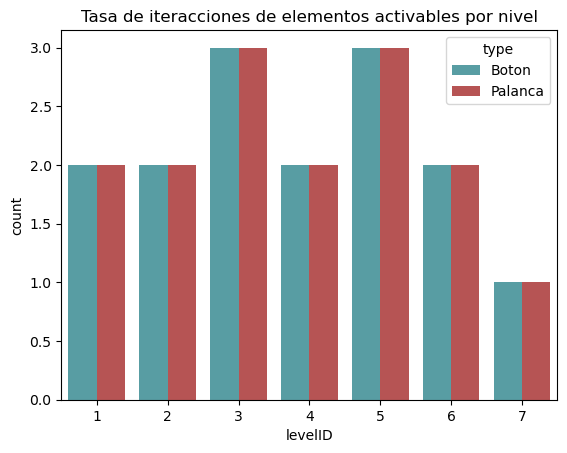

In [ ]:
buttonPressDB["type"] = "Boton"
leverActionDB["type"] = "Palanca"

combined = pd.concat([buttonPressDB, leverActionDB])

ax = sns.countplot(
    x="levelID",
    hue="type",
    data=combined,
    palette=["#4CA7AF", "#C64444"],
    order=sorted(combined["levelID"].unique())
)

ax.set_title("Tasa de iteracciones de elementos activables por nivel")
ax.tick_params(axis='x', rotation=0)

plt.show()

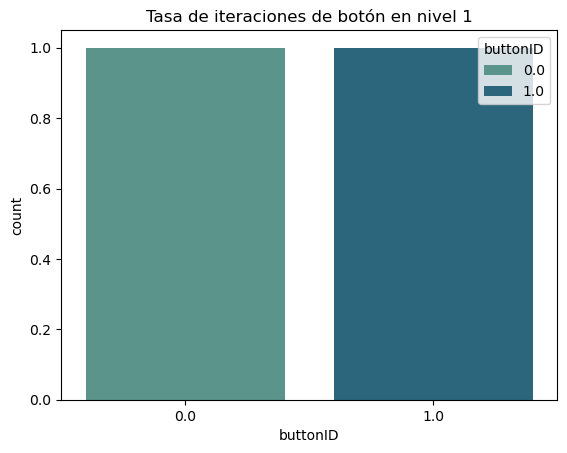

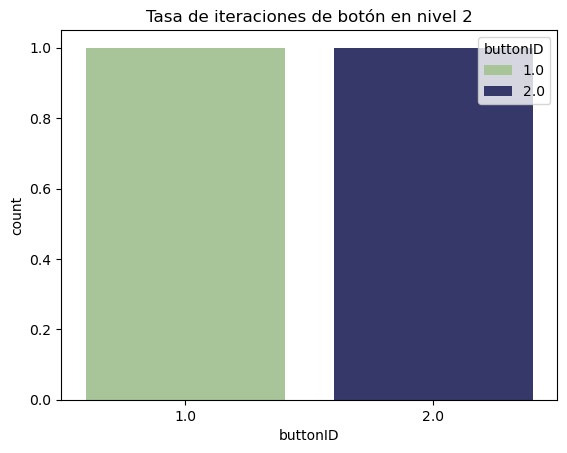

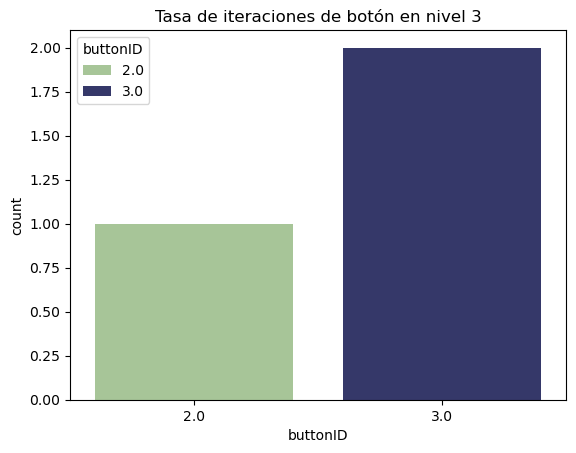

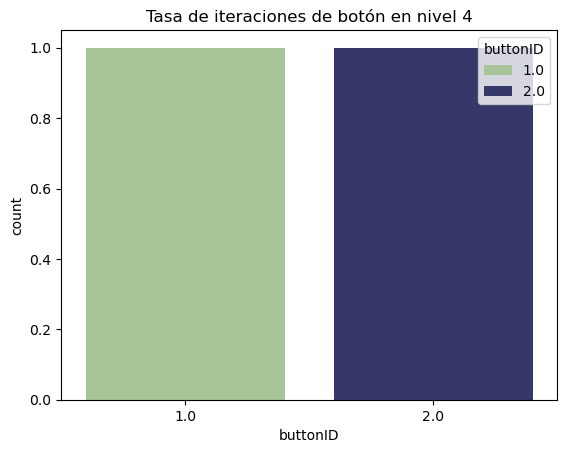

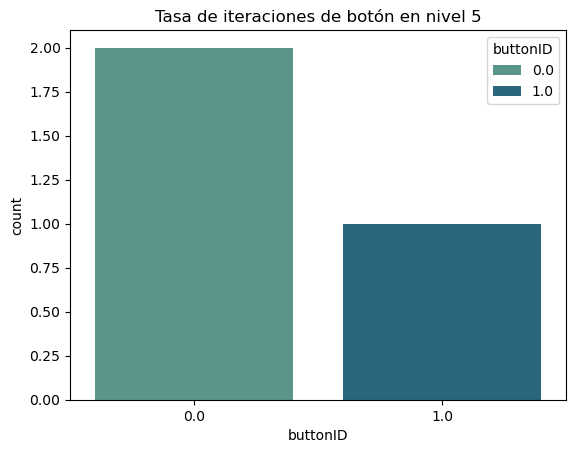

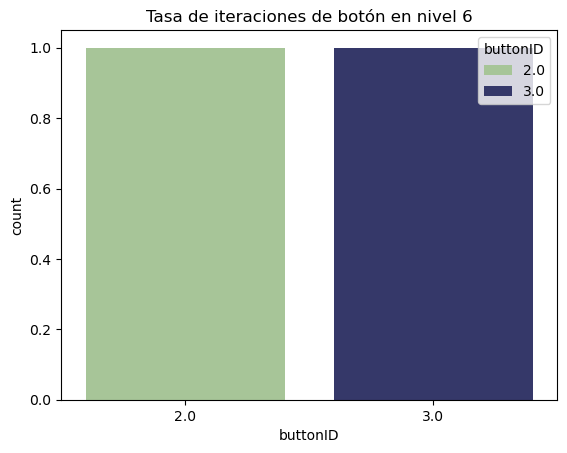

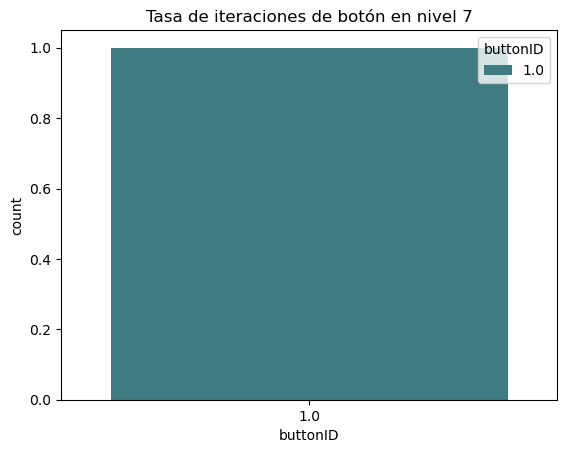

In [ ]:
buttonPressLevelsDS = []

for level in levelIdsValues:
    buttonPressLevelsDS.append(buttonPressDB[buttonPressDB["levelID"] == level])

for dataset in buttonPressLevelsDS:
    ax = sns.countplot(x="buttonID", data=dataset, hue="buttonID", palette = "crest")
    ax.set_title("Tasa de iteraciones de botón en nivel " + str(dataset["levelID"].iloc[0]))
    ax.tick_params(axis='x', rotation=0)
    plt.show()

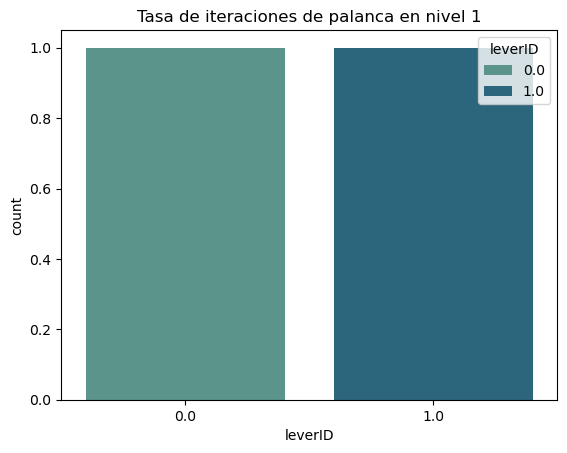

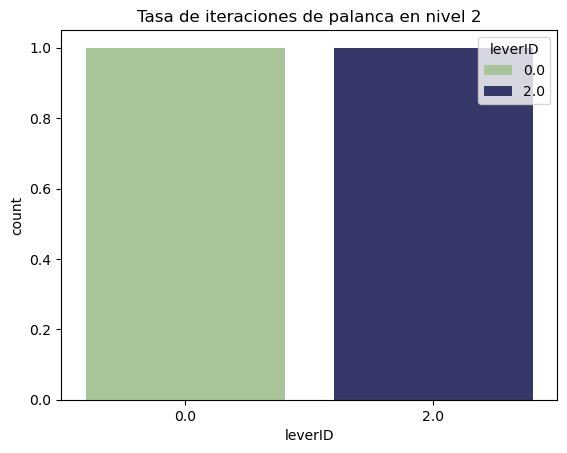

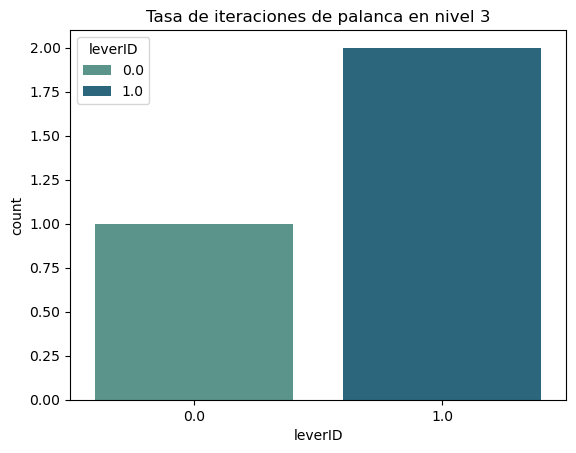

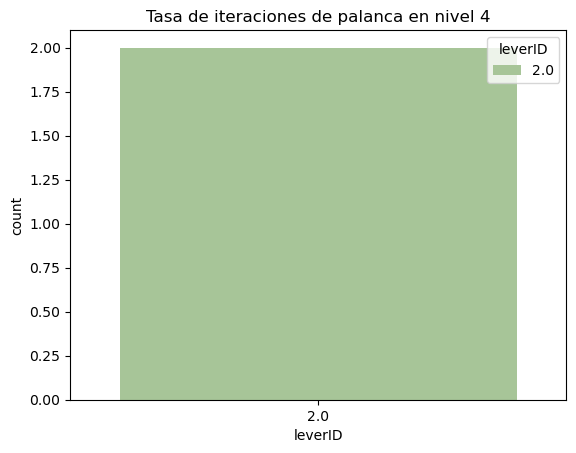

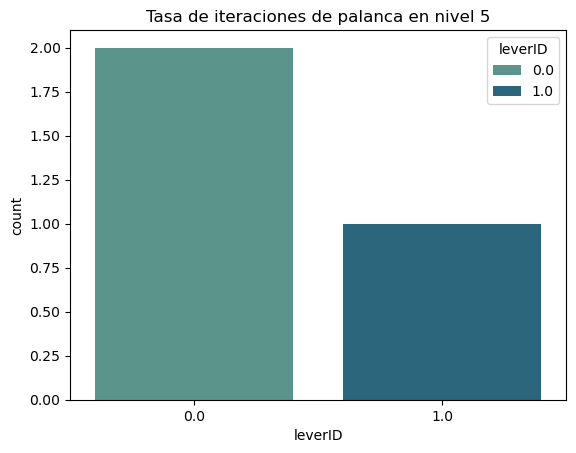

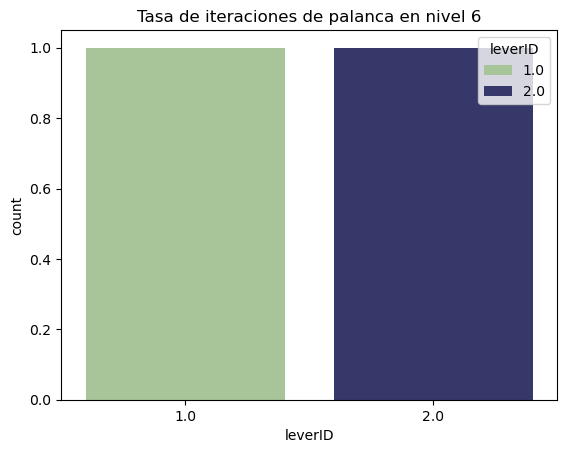

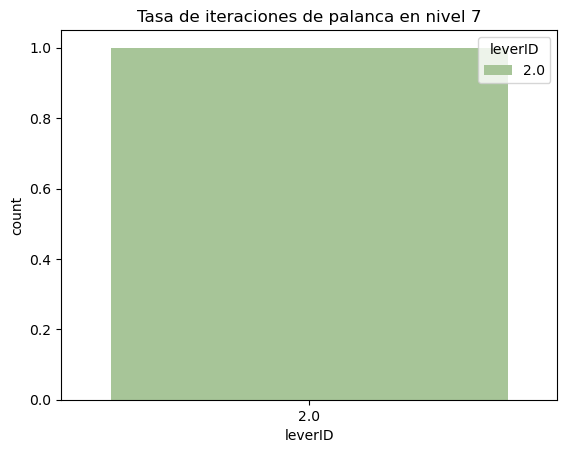

In [ ]:
leverActionLevelsDS = []

for level in levelIdsValues:
    leverActionLevelsDS.append(leverActionDB[leverActionDB["levelID"] == level])

for dataset in leverActionLevelsDS:
    ax = sns.countplot(x="leverID", data=dataset, hue="leverID", palette = "crest")
    ax.set_title("Tasa de iteraciones de palanca en nivel " + str(dataset["levelID"].iloc[0]))
    ax.tick_params(axis='x', rotation=0)
    plt.show()

### Tiempo que tardan los jugadores en pasarse un nivel y diferencia  de dicho tiempo respecto al ideal

## Fase 4, Respuesta a las Hipotesis segun las metricas

En esta fase, una vez analizadas las metricas y apoyandonos en su visualizacion, contrastaremos las hipotesis planteadas.